<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/module3_object_classification_practice_exercise_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Image Classification**
This is a task in CV where a computer is trained to look at an image and decide what it contains,you we give the model an image and it predicts a label for it.Classification models uses deep learning models.First we gice an input image then the model analyzes patterns,it compares these patterns to what it learned during training and it outputs a class label.

Object Recognition Using Regional Properties is a way to identify objects in an image by looking at the properties of each connected segment insted of analyzing the whole image pixel by pixel.This method is commonly used in computer vision after we already do image segmentation.First we split the image into regions,then we describe each object using numbers and finally we decide what the object is.Step one is to segment the image,we separate the image into regions with the methods that we learned in module 2,after that we have to extract regional properties which means that for every region we have to compute area,perimeter,centroid,shape etc.After that we have to compare these properties with known patterns.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


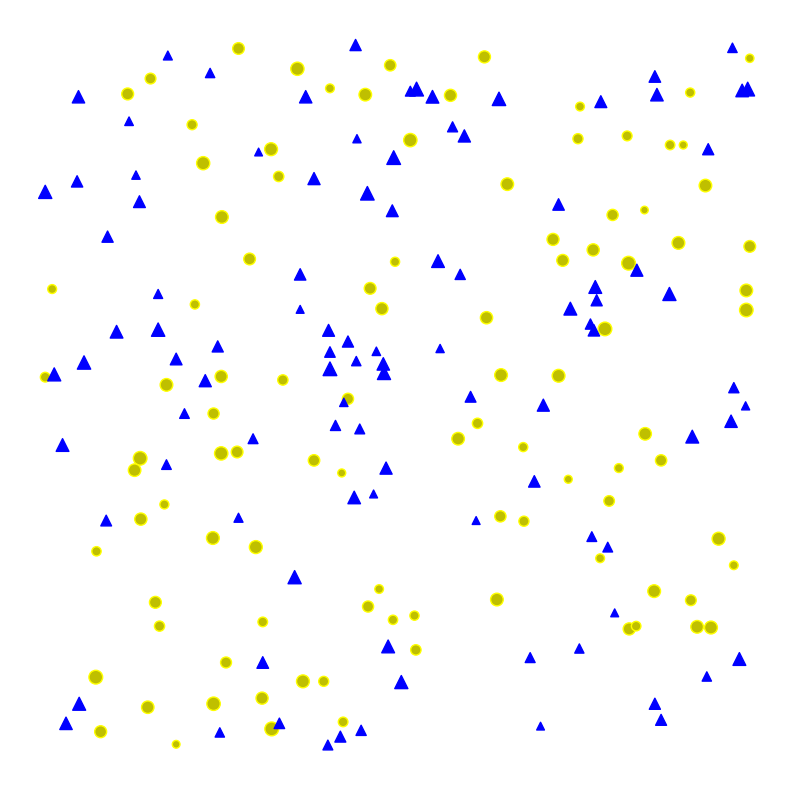

In [29]:
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
np.random.seed(13)
import matplotlib.pyplot as plt
Isize = 1024
N = 100
X = np.random.randint(Isize, size=(2,2*N))
fig = plt.figure(figsize=(10,10))
symsizes1 = np.random.randint(30,100,size=(1,N))
symsizes2 = np.random.randint(30,100,size=(1,N))
plt.scatter(X[0,0:N], X[1,0:N], s=symsizes1, c='y',edgecolor="yellow",marker = 'o')
plt.scatter(X[0,N:2*N], X[1,N:2*N], s=symsizes2, c='b',edgecolor="blue",marker = '^')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Patterns_result.png',dpi=600, facecolor='w',bbox_inches='tight')
plt.show()

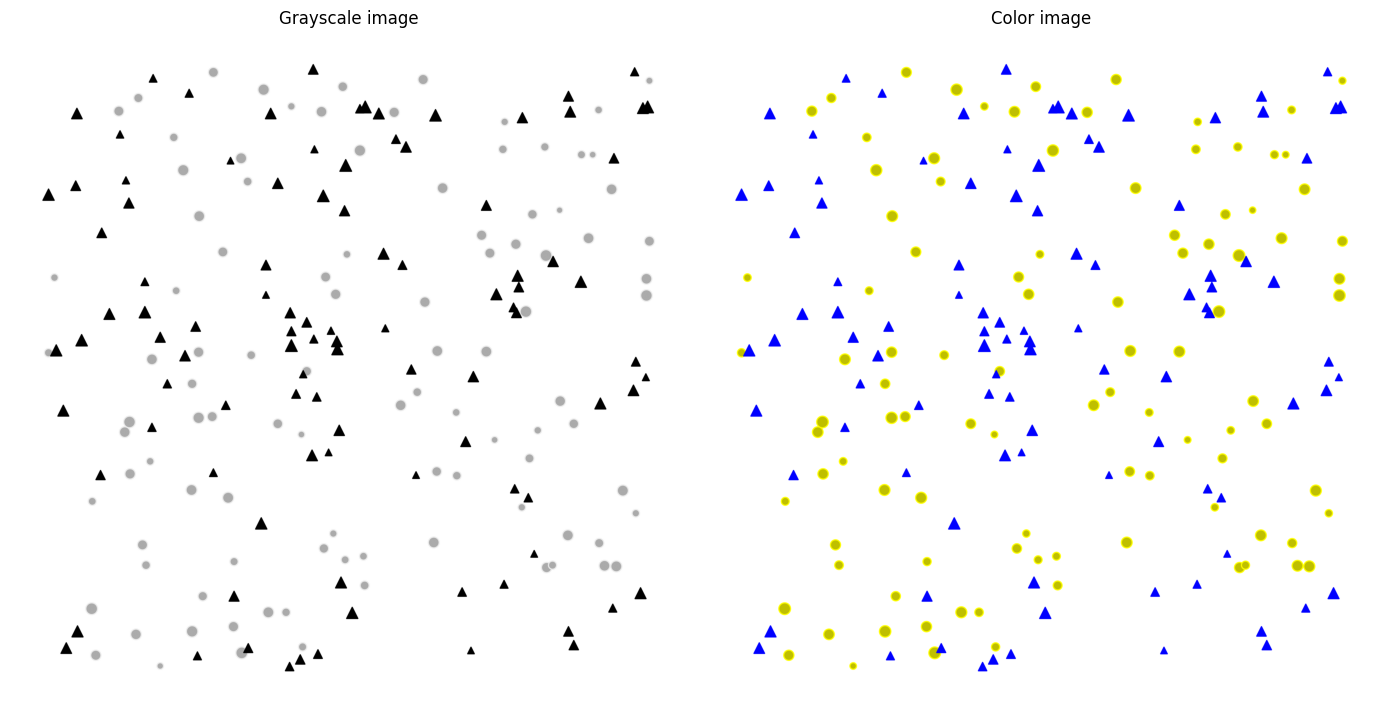

In [30]:
import matplotlib.pyplot as plt
from skimage import io
from skimage import data
from skimage.filters import threshold_otsu
from skimage.measure import label
I = io.imread('/content/drive/MyDrive/Colab Notebooks/Patterns_result.png',as_gray=True)
IC = io.imread('/content/drive/MyDrive/Colab Notebooks/Patterns_result.png')
fig, axes = plt.subplots(1,2,figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(I,cmap=plt.cm.gray)
ax[0].set_title('Grayscale image')
ax[1].imshow(IC,cmap=plt.cm.jet)
ax[1].set_title('Color image')
ax[0].set_axis_off()
ax[1].set_axis_off()
plt.tight_layout()
plt.show()

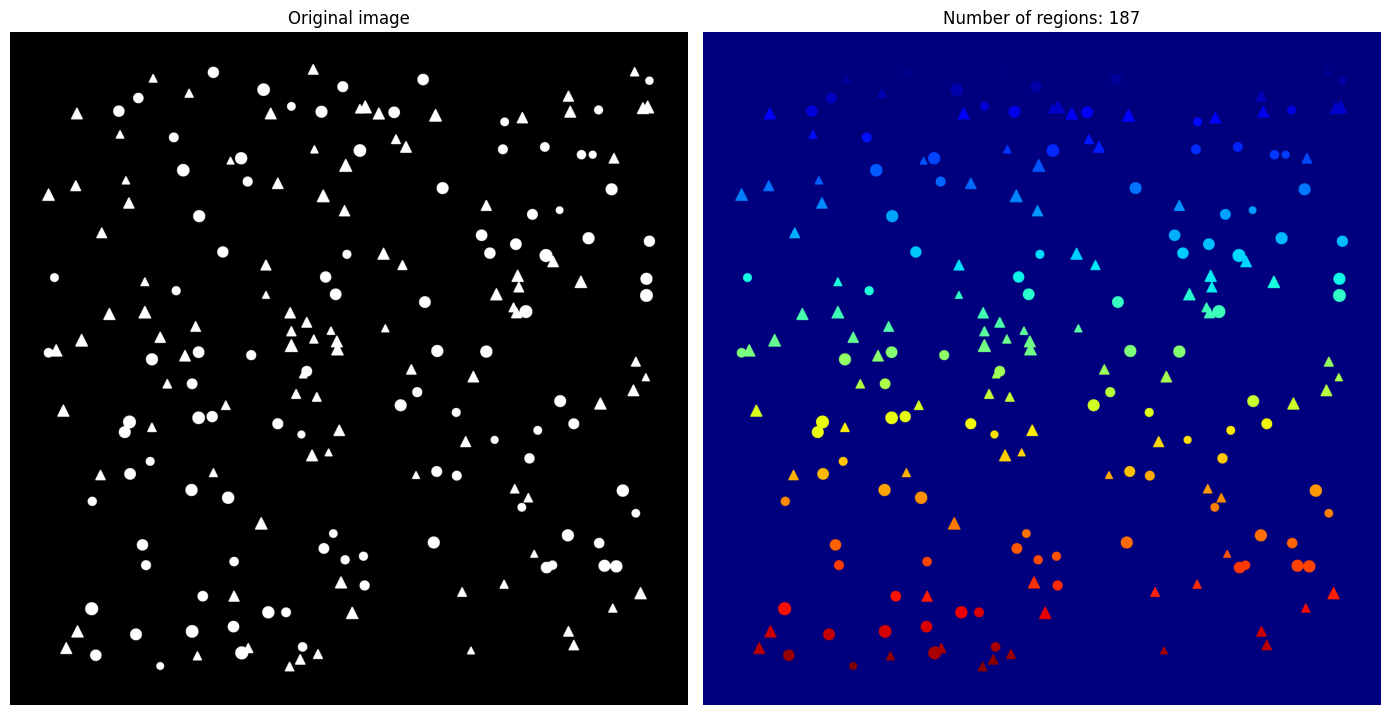

In [31]:
bw = np.logical_not(I==1)
label_image, nregions = label(bw,return_num=True)
fig, axes = plt.subplots(1,2,figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(bw,cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[1].imshow(label_image,cmap=plt.cm.jet)
ax[1].set_title('Number of regions: {}'.format(nregions))
ax[0].set_axis_off()
ax[1].set_axis_off()
plt.tight_layout()
plt.show()

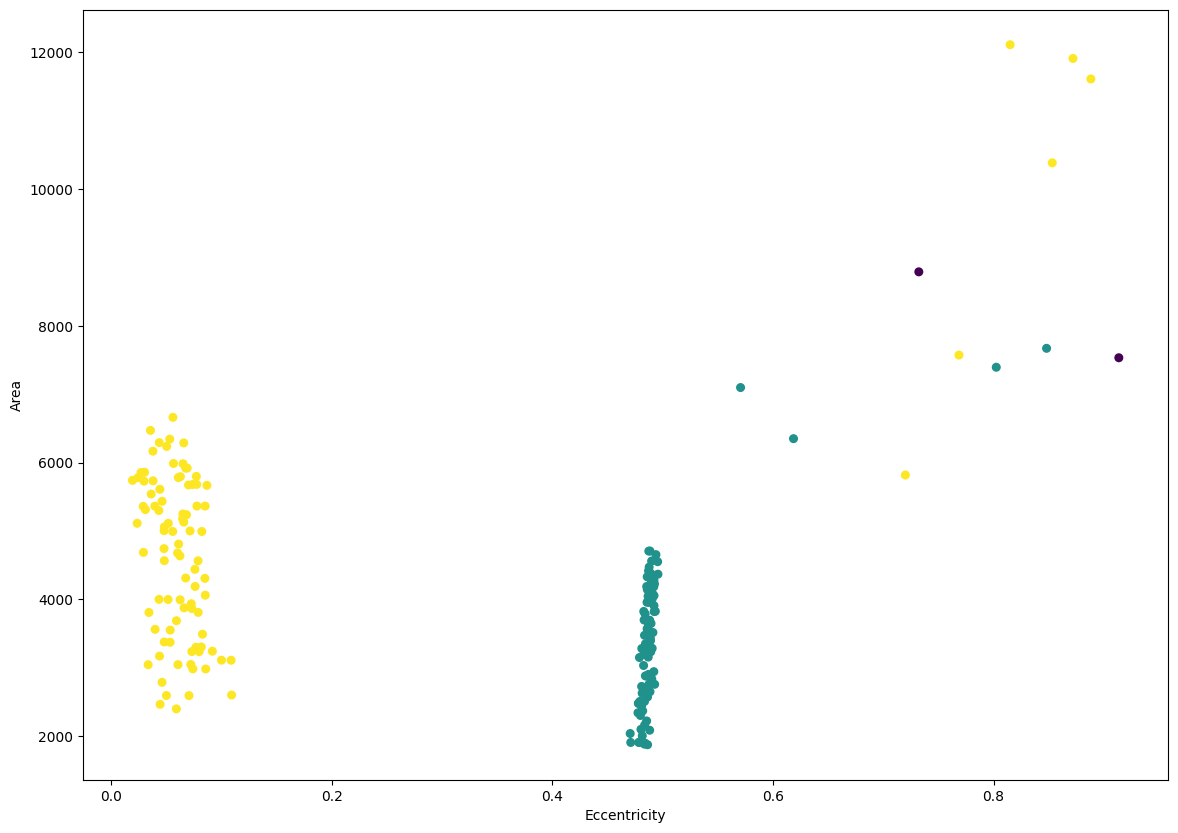

In [32]:
from skimage.measure import regionprops
props = regionprops(label_image)
features = np.zeros((nregions,3))
labels = np.zeros(nregions)
bw1 = np.array(IC[:,:,0]==0,dtype=np.uint8)
bw2 = np.array(IC[:,:,2]==0,dtype=np.uint8)
for i in range(0, nregions):
    features[i, 0] = props[i].eccentricity
    features[i, 1] = props[i].area
    features[i, 2] = props[i].solidity
    row = int(props[i].centroid[0])
    col = int(props[i].centroid[1])
    row = min(max(0, row), bw1.shape[0] - 1)
    col = min(max(0, col), bw1.shape[1] - 1)
    labels[i] = bw1[row, col] + 2 * bw2[row, col]
fig = plt.figure(figsize=(14,10))
plt.scatter(features[:,0], features[:,1], s=30, c=labels,marker = 'o')
plt.xlabel('Eccentricity')
plt.ylabel('Area')
plt.show()

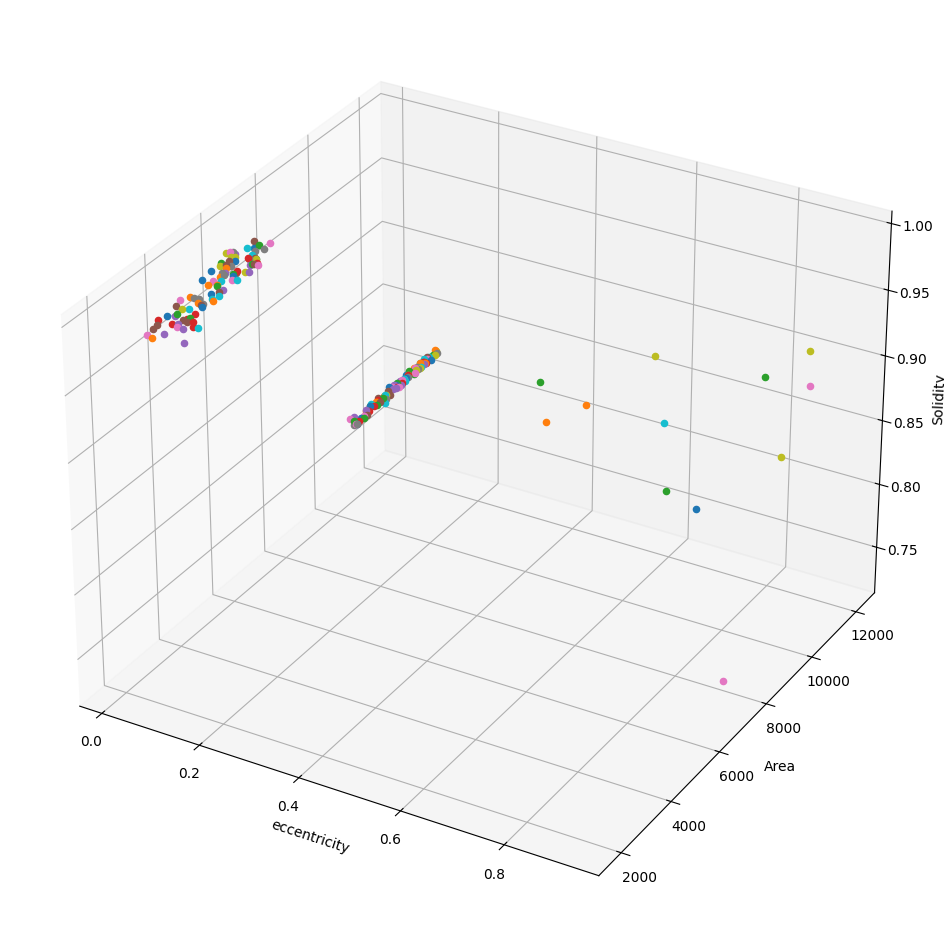

In [33]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
for k in range(features.shape[0]):
    xs = features[k,0]
    ys = features[k,1]
    zs = features[k,2]
    ax.scatter(xs, ys, zs, marker='o')
ax.set_xlabel('eccentricity')
ax.set_ylabel('Area')
ax.set_zlabel('Solidity')

plt.show()

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
NTRAIN = 50
clf = LinearDiscriminantAnalysis()
clf.fit(features[0:NTRAIN,:], labels[0:NTRAIN])
labels_pred = clf.predict(features[NTRAIN+1:-1])
labels_true = labels[NTRAIN+1:-1]
from sklearn.metrics import confusion_matrix
CM = confusion_matrix(labels_true,labels_pred)
from sklearn.metrics import classification_report
print(classification_report(labels_true,labels_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         2
         1.0       0.89      1.00      0.94        62
         2.0       1.00      0.92      0.96        71

    accuracy                           0.94       135
   macro avg       0.63      0.64      0.63       135
weighted avg       0.93      0.94      0.93       135



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
